## Часть 1: Основы построения решающие дерева (1.5 балла)

В этой части все расчёты необходимо реализовывать в виде запрограммированных формул, например, на `numpy`. **Нельзя использовать готовые реализации**. Например, если в задании требуется рассчитать энтропию, то требуется в каком-то виде релизовать расчёт по формуле, но нельзя использовать готовую реализацию `some_module.entropy()`.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Задание 1.1 (0.5 балла)** Пусть известно, что в вершину решающего дерева попали 10 объектов, 8 из которых имеют метку класса $k_1$, а 2 имеют метку класса $k_2$. Рассчитайте энтропию такого распределения классов (с натуральным логарифмом). Ответ округлите до двух знаков после запятой.

In [ ]:
l = 10
k1 = 8
k2 = 2
p1 = k1 / l
p2 = k2 / l
print(f'Энтропия распределения классов: {round(-(p1 * np.log(p1) + p2 * np.log(p2)), 2)}')

Энтропия распределения классов: 0.5


**Задание 1.2 (0.5 балла)** Пусть дополнительно известно, что вершина из предыдущего задания не является листовой и возможно такое разбиение, что в левое поддерево попадут все объекты класса $k_1$, а в правое - класса $k_2$. Посчитайте критерий информативности:

$$
Q(R_m, j, t) = H(R_m) - \frac{|R_\ell|}{|R_m|}H(R_\ell) - \frac{|R_r|}{|R_m|}H(R_r),
$$

где $R_m$ - множество объектов в разбиваемой вершине, $j$ - номер признака, по которому происходит разбиение, $t$ - порог разбиения, $R_\ell$ - множество объектов в левом поддереве, $R_r$ - множество объектов в правом поддереве.

Теперь в качестве $H(R)$ будем использовать индекс Джини:

$$
H(R) = \sum_{k=1}^J p_k(1-p_k),
$$
где $J$ – общее количество классов (в нашем случае, $J = 2$).

Ответ округлите до двух знаков после запятой.

In [ ]:
# так как в каждое поддерево попало по одному классу, в этих поддеревьях энтропия равна 0
# считаем энтропию только для R_m

H_Rm = p1 * (1 - p1) + p2 * (1 - p2)
print(f'Критерий информативности: Q(Rm, j, t) = {round(H_Rm, 2)}')

Критерий информативности: Q(Rm, j, t) = 0.32


**Задание 1.3 (0.5 балла)** Пусть при построении дерева образовалась листовая вершина с 10 объектами, значения целевой переменной для которых следующие: [1, 10, 5, 18, 100, 30, 50, 61, 84, 47] (решается задача регрессии). Чему будут равны предсказания модели для этих объектов?

In [ ]:
# в задаче регрессии предсказание в листе - среднее среди попавших туда значений
obj = np.array([1, 10, 5, 18, 100, 30, 50, 61, 84, 47])
print(f'Предсказание для модели = {obj.mean()}')

Предсказание для модели = 40.6


## Часть 2: Решающие деревья (4.5 балла)

В этой части мы напишем и протестируем собственную реализацию решающего дерева.

In [ ]:
from collections import Counter
from typing import Dict, List, Tuple, Union

**Задание 2.1 (1.5 балла)** Реализуйте функцию `find_best_split()`, которая должна находить оптимальное разбиение подмножества обучающей выборки в соответствии с информационным критерием из **Задания 1.2**. В качестве меры хаотичности $H(R)$ для задачи регрессии испольуйте дисперсию подвыборки, а для задачи классификации – критерий Джини (определён в том же задании).

Для категориальных признаков применяется наивный алгоритм разбиения: мы пытаемся найти одно значение, разбиение по которому сильнее всего увеличит критерий информативности. Иными словами, объекты с конкретным значением признака отправляем в левое поддерево, остальные - в правое. Обратите внимание, что это далеко не оптимальные способ учёта категориальных признаков. Например, можно было бы на каждое значение категориального признака создавать отдельное поддерево или использовать более сложные подходы. Подробнее об этом можно прочитать в конспектах [лекций](https://github.com/esokolov/ml-course-hse/blob/master/2019-fall/lecture-notes/lecture07-trees.pdf) по машинному обучению на ПМИ (раздел «Учёт категориальных признаков»).

В качестве подсказок реализации можете пользоваться кодом из бонусной части семинара по решающим деревьям.

**Бонус:** Разрешается делать цикл для перебора порогов, но возможна имплементация без него. За имплементацию без цикла – **бонус 1 балл**.

In [ ]:
def find_best_split(
    feature_vector: Union[np.ndarray, pd.DataFrame],
    target_vector: Union[np.ndarray, pd.Series],
    task: str = "classification",
    feature_type: str = "real"
) -> Tuple[np.ndarray, np.ndarray, float, float]:
    """
    Указания:
    * Пороги, приводящие к попаданию в одно из поддеревьев пустого множества объектов, не рассматриваются.
    * В качестве порогов, нужно брать среднее двух сосдених (при сортировке) значений признака
    * Поведение функции в случае константного признака может быть любым.
    * При одинаковых приростах Джини или дисперсии нужно выбирать минимальный сплит.
    * За наличие в функции циклов балл будет снижен. Векторизуйте! :)

    :param feature_vector: вещественнозначный вектор значений признака
    :param target_vector: вектор классов объектов,  len(feature_vector) == len(target_vector)
    :param task: либо `classification`, либо `regression`
    :param feature_type: либо `real`, либо `categorical`

    :return thresholds: отсортированный по возрастанию вектор со всеми возможными порогами, по которым объекты можно
     разделить на две различные подвыборки, или поддерева
    :return ginis: вектор со значениями критерия Джини для каждого из порогов в thresholds len(ginis) == len(thresholds)
    :return threshold_best: оптимальный порог (число)
    :return gini_best: оптимальное значение критерия Джини (число)
    """
    if type(feature_vector) == pd.Series:
        feature_vector = feature_vector.values
    if feature_type == 'real':
        feature_index_sort = np.argsort(feature_vector)

        d = np.ones(len(feature_vector) - 2) * 2
        d = np.insert(d, 0, 1)
        d = np.append(d, 1)
        feature_vector1 = np.repeat(feature_vector[feature_index_sort], list(d)).reshape(-1, 2)
        thresholds = feature_vector1.mean(axis=1)
        thresholds = np.sort(np.array(list(set(thresholds))))
        if feature_vector[feature_index_sort][0] == thresholds[0]:
            thresholds = thresholds[1:]
        target_sort = target_vector[feature_index_sort]
        if task == 'classification':
            ginis = np.array([])
            probs_Rm = np.array(list(dict(Counter(target_vector)).values())) / np.array(list(dict(Counter(target_vector)).values())).sum()
            H_Rm = (probs_Rm * (1 - probs_Rm)).sum()
            for t in thresholds:
                ind = (feature_vector[feature_index_sort] < t).sum()
                ind2 = (feature_vector[feature_index_sort] >= t).sum()
                c_left = dict(Counter(target_sort[:ind]))
                c_right = dict(Counter(target_sort[ind:]))
                prob_left = np.array(list(c_left.values())) / np.array(list(c_left.values())).sum()
                prob_right = np.array(list(c_right.values())) / np.array(list(c_right.values())).sum()
                gini_left = (prob_left * (1 - prob_left)).sum()
                gini_right = (prob_right * (1 - prob_right)).sum()
                ginis = np.append(ginis, H_Rm - (ind / len(target_vector)) * gini_left - (ind2 / len(target_vector)) * gini_right)
            max_gini = np.argmax(ginis)
            return thresholds, ginis, thresholds[max_gini], ginis[max_gini]
        elif task == 'regression':
            vars = np.array([])
            H_Rm = target_vector.var()
            for t in thresholds:
                ind = (feature_vector[feature_index_sort] < t).sum()
                ind2 = (feature_vector[feature_index_sort] >= t).sum()
                var_left = target_sort[:ind].var()
                var_right = target_sort[ind:].var()
                vars = np.append(vars, H_Rm - (ind / len(target_vector)) * var_left - (ind2 / len(target_vector)) * var_right)
            max_vars = np.argmax(vars)
            return thresholds, vars, thresholds[max_vars], vars[max_vars]
    elif feature_type == 'categorical':
        thresholds = np.array(list(set(feature_vector)))
        if task == 'classification':
            ginis = np.array([])
            probs_Rm = np.array(list(dict(Counter(target_vector)).values())) / np.array(list(dict(Counter(target_vector)).values())).sum()
            H_Rm = (probs_Rm * (1 - probs_Rm)).sum()
            for t in thresholds:
                c_left = dict(Counter(target_vector[feature_vector == t]))
                c_right = dict(Counter(target_vector[feature_vector != t]))
                prob_left = np.array(list(c_left.values())) / np.array(list(c_left.values())).sum()
                prob_right = np.array(list(c_right.values())) / np.array(list(c_right.values())).sum()
                gini_left = (prob_left * (1 - prob_left)).sum()
                gini_right = (prob_right * (1 - prob_right)).sum()
                ginis = np.append(ginis, H_Rm - (ind / len(target_vector)) * gini_left - (ind2 / len(target_vector)) * gini_right)
            max_gini = np.argmax(ginis)
            return thresholds, ginis, thresholds[max_gini], ginis[max_gini]
        elif task == 'regression':
            vars = np.array([])
            H_Rm = target_vector.var()
            for t in thresholds:
                var_left = target_vector[feature_vector == t].var()
                var_right = target_vector[feature_vector == t].var()
                vars = np.append(vars, H_Rm - (ind / len(target_vector)) * var_left - (ind2 / len(target_vector)) * var_right)
            max_vars = np.argmax(vars)
            return thresholds, vars, thresholds[max_vars], vars[max_vars]
    pass

Эту функцию можно протестировать на датасете `California`.

In [ ]:
from sklearn.datasets import fetch_california_housing

In [ ]:
data = fetch_california_housing()
X = pd.DataFrame(data=data["data"], columns=data["feature_names"])
y = data["target"]
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

Выведите график зависимости значения критерия ошибки от порогового значения при разбиении вершины по признаку `MedInc`.

In [ ]:
splitt = find_best_split(feature_vector=X['MedInc'], target_vector=y, task='regression', feature_type='real')

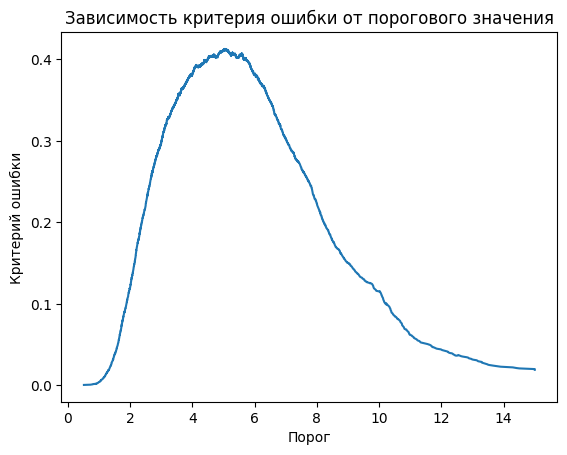

In [ ]:
porog = splitt[0]
oshibka = splitt[1]
plt.plot(porog, oshibka)
plt.xlabel('Порог')
plt.ylabel('Критерий ошибки')
plt.title('Зависимость критерия ошибки от порогового значения');

Найдите лучший, с вашей точки зрения, предикат первой вершины решающего дерева.

In [ ]:
best_porog = np.array([])
entr = np.array([])

for feature in X.columns.values:
    spl = find_best_split(feature_vector=X[feature], target_vector=y, task='regression', feature_type='real')
    best_porog = np.append(best_porog, spl[2])
    entr = np.append(entr, spl[3])

In [ ]:
best_entr_ind = np.argmax(entr)
best_best_porog = best_porog[best_entr_ind]

print(f'Лучшией предикат - разбиение выборки по признаку {X.columns.values[best_entr_ind]} по значению {best_best_porog}')

Лучшией предикат - разбиение выборки по признаку MedInc по значению 5.03515


**Задание 2.2 (1 балл)** Разберитесь с написанным кодом решающего дерева, заполните пропуски в коде и реализуйте недостающий метод `_predict_node()`.

Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции в разделе «Построение дерева».
- **Выбор лучшего разбиения** необходимо производить по критерию Джини.
- **Критерий останова:** все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку.
- **Ответ в листе:** наиболее часто встречающийся класс в листе.

В задаче также предлагается получить два бонуса, по баллу на каждый!

- **Реализуйте способ обрабатывать пропуски в даннх и реализуйте его, пояснив свои действия.**
- **Реализуйте метод оценки важности признаков.**

In [ ]:
class DecisionTree:

    def __init__(
        self,
        feature_types: Union[List[str], np.ndarray],
        max_depth: int = None,
        min_samples_split: int = None,
        min_samples_leaf: int = None,
        task: str = "classification"
    ) -> None:

        if np.any(list(map(lambda x: x != "real" and x != "categorical", feature_types))):
            raise ValueError("There is unknown feature type")

        # В этой переменной будем хранить узлы решающего дерева. Каждая вершина хранит в себе идентификатор того,
        # является ли она листовой. Листовые вершины хранят значение класса для предсказания, нелистовые - правого и
        # левого детей (поддеревья для продолжения процедуры предсказания)
        self._tree = {}

        # типы признаков (категориальные или числовые)
        self._feature_types = feature_types

        # гиперпараметры дерева
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf
        self.task = task

        # Переменная, если вы решите делать бонус
        self._feature_importances = {}


    def _fit_node(
        self,
        sub_X: np.ndarray,
        sub_y: np.ndarray,
        node: dict
    ) -> None:

        # критерий останова
        if np.all(sub_y == sub_y[0]):
            node["type"] = "terminal"
            node["class"] = sub_y[0]
            return

        feature_best, threshold_best, gini_best, split = None, None, None, None
        for feature in range(sub_X.shape[1]):
            feature_type = self._feature_types[feature]
            categories_map = {}

            # подготавливаем признак для поиска оптимального порога
            if feature_type == "real":
                feature_vector = sub_X[:, feature]
            elif feature_type == "categorical":
                # здесь могла быть реализация более сложного подхода к обработке категориального признака
                feature_vector = sub_X[:, feature]

            # ищем оптимальный порог
            _, _, threshold, gini = find_best_split(feature_vector, sub_y, self.task, feature_type)

            if gini_best is None or gini > gini_best:
                feature_best = feature
                gini_best = gini

                # split - маска на объекты, которые должны попасть в левое поддерево
                if feature_type == "real":
                    threshold_best = threshold
                    split = # ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
                elif feature_type == "categorical":
                    # в данной реализации это просто значение категории
                    threshold_best = threshold
                    split = # ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
                else:
                    raise ValueError

        # записываем полученные сплиты в атрибуты класса
        if feature_best is None:
            node["type"] = "terminal"
            node["class"] = Counter(sub_y).most_common(1)[0][0]
            return

        node["type"] = "nonterminal"

        node["feature_split"] = feature_best
        if self._feature_types[feature_best] == "real":
            node["threshold"] = threshold_best
        elif self._feature_types[feature_best] == "categorical":
            node["category_split"] = threshold_best
        else:
            raise ValueError

        node["left_child"], node["right_child"] = {}, {}
        self._fit_node(sub_X[split], sub_y[split], node["left_child"])
        self._fit_node(sub_X[np.logical_not(split)], sub_y[np.logical_not(split)], node["right_child"])

    def _predict_node(self, x: np.ndarray, node: dict) -> int:
        """
        Предсказание начинается с корневой вершины дерева и рекурсивно идёт в левое или правое поддерево в зависимости от значения
        предиката на объекте. Листовая вершина возвращает предсказание.
        :param x: np.array, элемент выборки
        :param node: dict, вершина дерева
        """
        # ᕕ(╭ರ╭ ͟ʖ╮•́)⊃¤=(————
        pass

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        self._fit_node(X, y, self._tree)

    def predict(self, X: np.ndarray) -> np.ndarray:
        predicted = []
        for x in X:
            predicted.append(self._predict_node(x, self._tree))

        return np.array(predicted)

SyntaxError: invalid syntax (<ipython-input-110-317b9054c80b>, line 68)

**Задание 2.3 (1 балл)** Загрузите таблицу `students.csv` (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте диаграммы рассеяния "значение признака — класс" для всех пяти признаков.

In [ ]:
data1 = pd.read_csv('https://raw.githubusercontent.com/hse-ds/iad-intro-ds/master/2024/homeworks/hw07-trees/students.csv').drop('Unnamed: 0', axis=1)
y2 = data1['UNS']
X2 = data1.drop('UNS', axis=1)

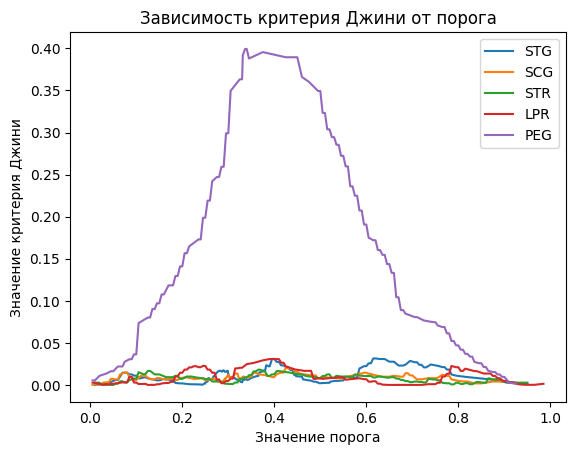

In [ ]:
for feature in X2.columns.values:
    spl1 = find_best_split(feature_vector=X2[feature], target_vector=y2, task='classification', feature_type='real')
    porog1 = spl1[0]
    oshibka1 = spl1[1]
    plt.plot(porog1, oshibka1)
plt.title('Зависимость критерия Джини от порога')
plt.xlabel('Значение порога')
plt.ylabel('Значение критерия Джини')
plt.legend(X2.columns.values);

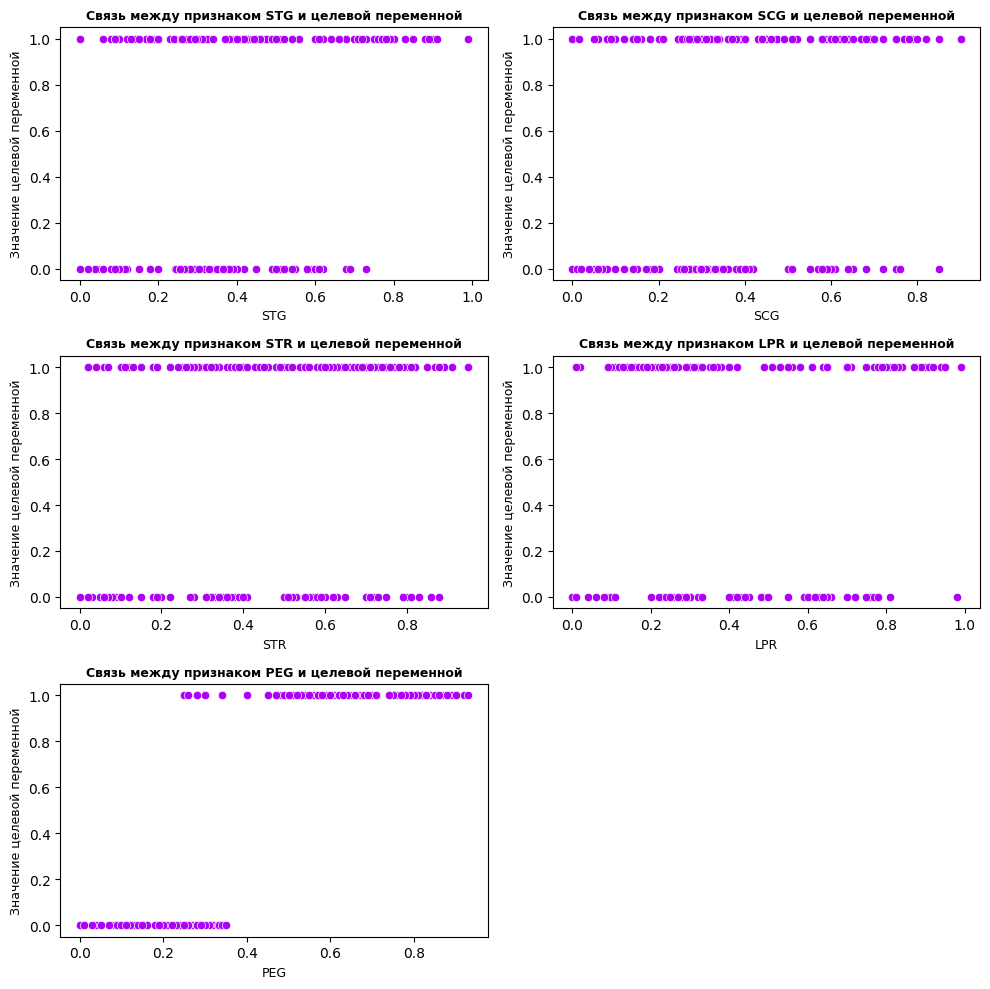

In [ ]:
import seaborn as sns
from matplotlib import gridspec
import itertools
fig = plt.figure(figsize = (10, 10))
gr = gridspec.GridSpec(3, 2)
features = X2.columns.values
for feature, grd in zip(features, itertools.product([0, 1, 2], [0, 1])):
    ax = plt.subplot(gr[grd[0], grd[1]])
    ax = sns.scatterplot(x=X2[feature], y=y2, color='#AD00F5')
    ax.set_title(f'Связь между признаком {feature} и целевой переменной', fontsize = 9, fontweight='heavy')
    ax.set_xlabel(feature, fontsize = 9)
    ax.set_ylabel('Значение целевой переменной', fontsize = 9)
fig.tight_layout()
plt.show()

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой диаграмм рассеяиния? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

**Ответ:** Самым лучшим признаком для разбиения является PEG, так как при разбиении по нему достигается максимальное значение критерия информативности. С диаграммой рассеивания это согласуется, так как на ней видно четкое разделение на два класса по данному признаку, практически идеально часть данных с таргетом ноль лежит в левой части, а с таргетом 1 - в правой. Поэтому деревьям легко разделить объекты по данному признаку.

Вид хороших признаков похож на функцию плотности нормального распределения, или параболу ветвями вниз, у нее есть пик, то есть максимальное значение, причем отличающееся от 0. У плохих признаков критерий информативности лежит около нуля при всех значениях порога, поэтому при любом пороге деление выборки будет плохим.

## Часть 3: Бэггинг и случайный лес (4 балла)

В данной части мы будем работать [с задачей предсказания диабета у пациента](https://www.kaggle.com/uciml/pima-indians-diabetes-database/data). Посмотрим на работу бэггинга над решающими деревьями и случайного леса, сравним их работу.

In [ ]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [ ]:
data = pd.read_csv('https://raw.githubusercontent.com/hse-ds/iad-intro-ds/master/2024/homeworks/hw07-trees/diabetes.csv')
print(f"Dataset shape: {data.shape}")
data.head()

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Посмотрим на распределение целевой переменной

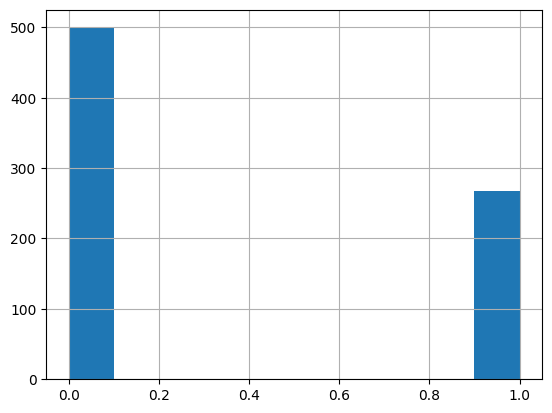

In [ ]:
data['Outcome'].hist()
plt.show()

**Задание 3.1 (0.5 балла)** Разделите данные на признаки и целевую переменную. Разбейте датасет на обучающую и тестовую части в отношении 7:3. Затем разделите обучающую выборку на обучающую-обучающую и обучающую-валидационную в соотношении 7:3 (то есть в итоге должно получиться три выборки: обучающая-обучающая (0.49 от исходного датасета), обучающая-валидационная (0.21 от исходного датасета) и тестовая (0.3 от исходного датасета).

In [ ]:
X = data.drop('Outcome', axis=1)
y = data['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
X_train_tr, X_val, y_train_tr, y_val = train_test_split(X_train, y_train, test_size=0.3, stratify=y_train, random_state=0)

**Задание 3.2 (1 балл)** На обучающей-валидационной выборке подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_leaf` для `DecisionTreeClassifier`. Для этого:
1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений обучите дерево на обучающей-обучающей выборке и определите качество на обучающей-валидационной выборке. В качестве критерия будем использовать `f1-меру`.
3. Выберите ту пару значений, которая даёт наилучшее качество на обучающей-валидационной выборке.


Обучите решающее дерево с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по метрикам `accuracy`, `precision` и `recall`, `auc_roc`.

In [ ]:
depth = range(1, 30)
samples_leaf = range(1, 30)
depth_sampl = []
f1 = np.array([])
for i in depth:
    for j in samples_leaf:
        clf = DecisionTreeClassifier(max_depth=i, min_samples_leaf=j)
        clf.fit(X_train_tr, y_train_tr)
        y_pred_val = clf.predict(X_val)
        depth_sampl.append((i, j))
        f1 = np.append(f1, f1_score(y_val, y_pred_val))


best_pair = np.argmax(f1)
print(f'Лучшая пара max_depth, min_samples_leaf: {depth_sampl[best_pair]} с f1-мерой = {f1[best_pair]}')

Лучшая пара max_depth, min_samples_leaf: (4, 25) с f1-мерой = 0.6229508196721312


In [ ]:
clf = DecisionTreeClassifier(max_depth=4, min_samples_leaf=25)
clf.fit(X_train, y_train)
y_pred_test = clf.predict(X_test)
print(f'Accuracy on test with DecisionTreeClassifier = {accuracy_score(y_test, y_pred_test)}')
print(f'Precision on test with DecisionTreeClassifier = {precision_score(y_test, y_pred_test)}')
print(f'Recall on test with DecisionTreeClassifier = {recall_score(y_test, y_pred_test)}')
print(f'AUC-ROC on test with DecisionTreeClassifier = {roc_auc_score(y_test, y_pred_test)}')

Accuracy on test with DecisionTreeClassifier = 0.7619047619047619
Precision on test with DecisionTreeClassifier = 0.6625
Recall on test with DecisionTreeClassifier = 0.654320987654321
AUC-ROC on test with DecisionTreeClassifier = 0.7371604938271605


**Задание 3.3 (0.5 балла)** Обучите [`BaggingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html) на 50 деревьях на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по тем же метрикам.

In [ ]:
bag_cl = BaggingClassifier(n_estimators=50)
bag_cl.fit(X_train, y_train)
y_pred_bag = bag_cl.predict(X_test)
print(f'Accuracy on test with BaggingClassifier= {accuracy_score(y_test, y_pred_bag)}')
print(f'Precision on test with BaggingClassifier= {precision_score(y_test, y_pred_bag)}')
print(f'Recall on test with BaggingClassifier = {recall_score(y_test, y_pred_bag)}')
print(f'AUC-ROC on test with BaggingClassifier = {roc_auc_score(y_test, y_pred_bag)}')

Accuracy on test with BaggingClassifier= 0.7619047619047619
Precision on test with BaggingClassifier= 0.703125
Recall on test with BaggingClassifier = 0.5555555555555556
AUC-ROC on test with BaggingClassifier = 0.7144444444444444


**Задание 3.4 (1 балл)** Выполните кросс-валидацию на полной обучающей выборке и подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_split` для `Random Forest` с 50 деревьями. Для этого:

1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений проведите кросс-валидацию на полной обучающей выборке. Количество разбиений выберите на ваш вкус. В качестве критерия будем использовать `f1-меру`. Усредните значение критерия по всем прогонам кросс-валидации.
3. Выберите ту пару значений, которая даёт наилучшее среднее качество.

Обучите случайный лес с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации по тем же метрикам. Какая из трёх построенных моделей показала себя лучше?

In [ ]:
from sklearn.model_selection import GridSearchCV
searcher = GridSearchCV(
    RandomForestClassifier(n_estimators=50, random_state=0), [{'max_depth': range(1, 20), 'min_samples_split': range(2, 20)}],
    scoring='f1', cv=5
)
searcher.fit(X_train, y_train)
best_depth = searcher.best_params_['max_depth']
best_sampl_split = searcher.best_params_['min_samples_split']

In [ ]:
best_depth, best_sampl_split

(9, 2)

In [ ]:
rf_clf = RandomForestClassifier(n_estimators=50, random_state=0, max_depth=best_depth, min_samples_split=best_sampl_split)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
print(f'Accuracy on test with RandomForestClassifier = {accuracy_score(y_test, y_pred_rf)}')
print(f'Precision on test with RandomForestClassifier = {precision_score(y_test, y_pred_rf)}')
print(f'Recall on test with RandomForestClassifier = {recall_score(y_test, y_pred_rf)}')
print(f'AUC-ROC on test with RandomForestClassifier = {roc_auc_score(y_test, y_pred_rf)}')

Accuracy on test with RandomForestClassifier = 0.7878787878787878
Precision on test with RandomForestClassifier = 0.7285714285714285
Recall on test with RandomForestClassifier = 0.6296296296296297
AUC-ROC on test with RandomForestClassifier = 0.7514814814814815


**Ответ:** Лучше всего показал себя случайный лес, только Recall у него немного хуже, чем у решающих деревьев.

**Задание 3.5 (0.5 балла)** Постройте график зависимости AUC ROC на тестовой выборке от числа деревьев (`n_estimators`) для случайного леса, обучаемого на **полной обучающей** выборке. Какие выводы можно сделать?

In [ ]:
auc_roc = []
est = range(2, 200)
for n in est:
    rf_clf2 = RandomForestClassifier(n_estimators=n, random_state=0, max_depth=best_depth, min_samples_split=best_sampl_split)
    rf_clf2.fit(X_train, y_train)
    y_pred_rf_test = rf_clf2.predict(X_test)
    auc_roc.append(roc_auc_score(y_test, y_pred_rf_test))

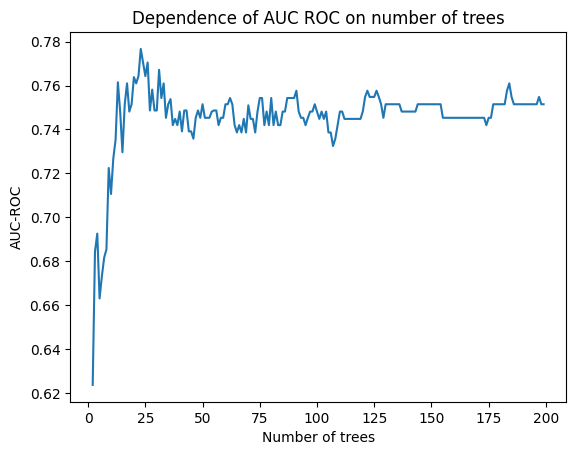

In [ ]:
plt.plot(est, auc_roc)
plt.title('Dependence of AUC ROC on number of trees')
plt.xlabel('Number of trees')
plt.ylabel('AUC-ROC');

**Ответ:** Видно, что AUC-ROC после некоторого значения количества деревьев (примерно 40-50) выходит на асимптоту и в целом не меняется в дальнейшем. То есть нет смысла увеличивать число деревьев, можно остановиться примерно на 50.

**Задание 3.6 (0.5 балла)** Для лучшей модели случайного леса из **Задания 3.4** посчитайте важность признаков и постройте bar plot. Какой признак оказался самым важным для определения диабета?

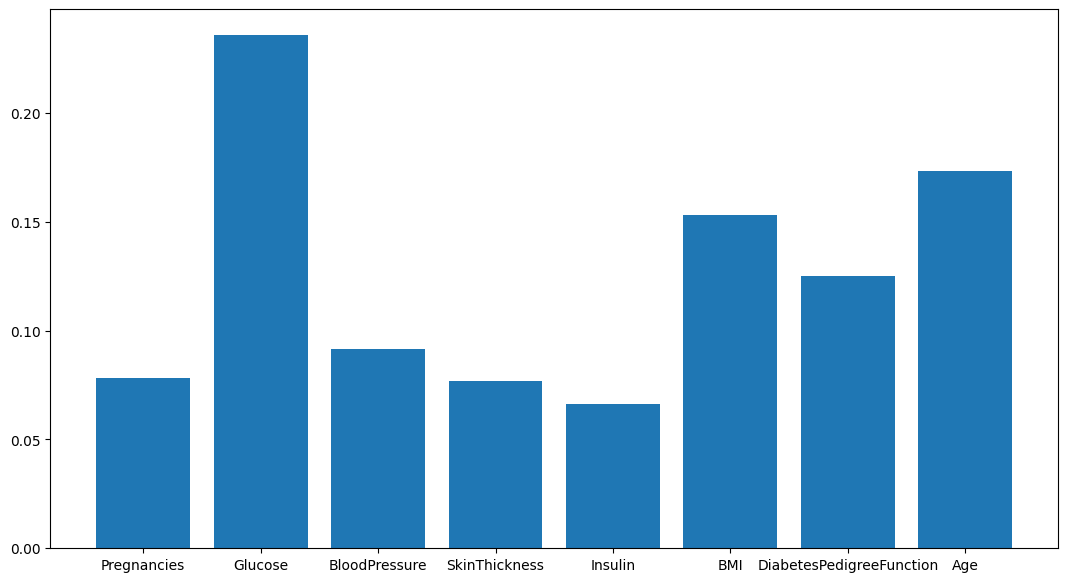

In [ ]:
fig = plt.figure(figsize = (13, 7))
plt.bar(X.columns.values, rf_clf.feature_importances_);

**Ответ:** Самым важным для определения диабета оказалось показание уровня глюкозы.